In [1]:
# source ../.venv/bin/activate

# trzeba uruchomic jupyter lab z tego juz dzialajacego srodowiska


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import math


print("ok")

ok


Basic form of LF:

$$
\phi(m) = A\,10^{\alpha(m-m_{\rm TRGB})}
$$

where $\alpha$ is around 0.3. 

auxiliary
$10^\alpha = e^\lambda$ and $\lambda = \alpha \cdot ln10$

We draw from 0 to 1 and transform with inverse CDF. $W$ is the range of magnitudes. 

$$
m =
m_{\rm TRGB}
+
\frac{1}{\alpha\ln 10}
\ln\!\left[
1 + u\left(10^{\alpha W}-1\right)
\right]
$$

In [3]:
# --------------------------------------------
# Sampler LF z CDF z liczba gwiazd i TRGB
# --------------------------------------------

def rgb_lf(m_trgb, alpha=0.3, m_range=5.0, N_stars = 1000):
    lam = alpha * math.log(10)

    u = np.random.uniform(0.0, 1.0, size=N_stars)

    m = m_trgb + (1.0 / lam) * np.log(1.0 + u * (10.0**(alpha * m_range) - 1.0))

    return m
    
    

In [4]:
m = rgb_lf(10,alpha=0.3, m_range=5.0, N_stars = 1000)
print(len(m),min(m),max(m))

1000 10.00520965494189 14.99776863980993


wspolczynnik przeliczenia ile gwiazd totalnie aby miec np. 100 gwiazd w 100 mag

$$
N_{\rm total} = N_{1mag} \cdot \frac{10^{\alpha W}-1}{10^{\alpha}-1}
$$

In [5]:
# -------------------------------------------
# wspolczynnik przeliczenia N_1mag
# k = k1mag(alpha=0.3,N1mag=100)
# N_tot = 100 * k
# -------------------------------------------

def k1mag(alpha=0.3, m_range=5.0):
    lam = alpha * math.log(10)
    k = (math.exp(lam * m_range) - 1.0) / (math.exp(lam) - 1.0)
    return k

In [6]:
N1mag = 100
k = k1mag(alpha=0.3,m_range=5.0)
N_tot = int(N1mag * k)
m = rgb_lf(10,alpha=0.3, m_range=5.0, N_stars = N_tot)
print("N total: ", len(m))
m = np.array(m)
maska = m < 11
m1 = m[maska]
print("N 1 mag: ", len(m1))



N total:  3076
N 1 mag:  115


In [7]:
def rgb_1mag(m_trgb, alpha=0.3, m_range=5.0, N_1mag = 1000):
    k = k1mag(alpha=alpha,m_range=m_range)
    N_tot = int(N_1mag * k)
    m = rgb_lf(m_trgb,alpha=alpha, m_range=m_range, N_stars = N_tot)
    m = _add_rgb(m,m_trgb=m_trgb, alpha=alpha, m_range=m_range, N_1mag = N_1mag)
    return m

def _add_rgb(m, m_trgb=10, alpha=0.3, m_range=5.0, N_1mag=1000):
    m = np.array(m)
    it = ""

    while True:
        m = np.array(m)
        maska = m < m_trgb + 1
        m1 = m[maska]
        dn = len(m1) - N_1mag
        
        
        if dn == 0:
            print(it)
            break

        if dn < 0:
            if abs(dn) > 5:
                k = k1mag(alpha=alpha, m_range=m_range)
                N_tot = round(abs(dn) * k)
                it = it + "#"
            else:
                N_tot = 1
                it = it + "+"

            am = rgb_lf(m_trgb,alpha=alpha,m_range=m_range,N_stars=N_tot)
            m = np.concatenate([m, am])

        elif dn > 0:
            if abs(dn) > 5:
                k = k1mag(alpha=alpha, m_range=m_range)
                n_remove = int(abs(dn) * k)
                it = it + "&"
            else:
                n_remove = 1
                it = it + "-"

            n_remove = min(n_remove, len(m))  # zabezpieczenie

            idx = np.random.choice(len(m), size=n_remove, replace=False)
            m = np.delete(m, idx)
            
    return m
            
    
        
        
    

In [8]:
m_trgb = 10
m = rgb_1mag(m_trgb, alpha=0.3, m_range=5.0, N_1mag = 100)
print("N total: ", len(m))
m = np.array(m)
maska = m < 11
m1 = m[maska]
print("N 1 mag: ", len(m1))
m_old = m

------------------------------------------------------------------------------------------------------------------------
N total:  2956
N 1 mag:  100


In [9]:
def rgb_lf(m_trgb, alpha=0.3, m_range=5.0, N_stars = 1000, N_1mag=None):
    lam = alpha * math.log(10)
    if N_1mag is None:
        u = np.random.uniform(0.0, 1.0, size=N_stars)
        m = m_trgb + (1.0 / lam) * np.log(1.0 + u * (10.0**(alpha * m_range) - 1.0))
    else:
        k = k1mag(alpha=alpha,m_range=m_range)
        N_tot = round(N_1mag * k)
        N = N_tot - N_1mag
        u = np.random.uniform(0.0, 1.0, size=N_1mag)
        m1 = m_trgb + (1.0 / lam) * np.log(1.0 + u * (10.0**(alpha * 1) - 1.0))
        u = np.random.uniform(0.0, 1.0, size=N)
        m2 = m_trgb + 1 + (1.0 / lam) * np.log(1.0 + u * (10.0**(alpha * (m_range-1)) - 1.0))
        m = np.concatenate((m1, m2))
        np.random.shuffle(m)
        
    return m

In [10]:
m_trgb = 10
m = rgb_lf(m_trgb, alpha=0.3, m_range=5.0, N_1mag = 100)
print("N total: ", len(m))
m = np.array(m)
maska = m < 11
m1 = m[maska]
print("N 1 mag: ", len(m1))

N total:  3077
N 1 mag:  100


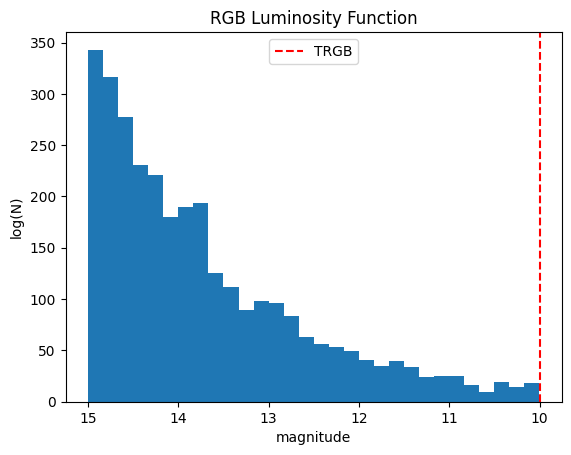

In [11]:
plt.figure()

plt.hist(m, bins=30, histtype='bar')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
#plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [12]:

# ------------------------------------------------------------
# magnitude → flux
# ------------------------------------------------------------

def mag_to_flux(m):
    return 10 ** (-0.4 * m)


def flux_to_mag(f):
    return -2.5 * math.log10(f)


# ------------------------------------------------------------
# blending model
# ------------------------------------------------------------

def build_blended_catalog(mags, p_pair=0.1):
    """
    Zwraca:
    - mags (oryginalne)
    - mags_blend (po blendingu)
    - pairs (diagnostyka)
    """

    mags_blend = []
    pairs = []

    for m1 in mags:

        if random.random() < p_pair:

            m2 = random.choice(mags)

            f1 = mag_to_flux(m1)
            f2 = mag_to_flux(m2)

            m_tot = flux_to_mag(f1 + f2)

            mags_blend.append(m_tot)
            pairs.append((m1, m2, m_tot))

        else:
            mags_blend.append(m1)

    return mags, mags_blend, pairs

In [13]:

mt, mb, pair = build_blended_catalog(m, p_pair=0.05)

print(10-min(mb))


-0.005142946435688245


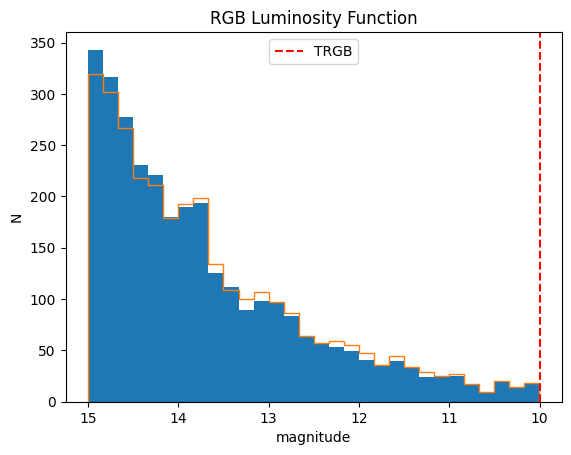

In [14]:
plt.figure()

plt.hist(mt, bins=30, histtype='bar')
plt.hist(mb, bins=30, histtype='step')
# 'bar', 'barstacked', 'step', 'stepfilled'

plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')


#plt.yscale('log') 

plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("N")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [15]:
# dodanie tla powyzej trgb

m_trgb = 10

m_rgb = rgb_lf(m_trgb, alpha=0.3, m_range=5.0, N_1mag = 500)
m_agb = rgb_lf(8, alpha=0.1, m_range=2.0, N_1mag = 20)

m = np.concatenate((m_rgb,m_agb))


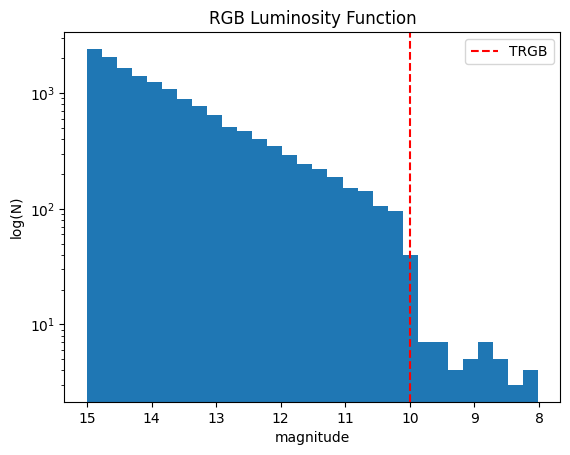

In [16]:
plt.figure()

plt.hist(m, bins=30, histtype='bar')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [17]:

#=================== FILTR POISSON NOISE =======================================  

#x,f=poisson(m,1,["step=0.01","sigma=0.05"])
def poisson(m,d,params):

    step=0.01
    sigma=0.00
    mmin = m.min()
    mmax = m.max()-d
    if len(params)>0:
       for par in params:
    	   if "step=" in par: 
               step=float(par.split("=")[1])
               if "sigma=" in par: 
                   sigma=float(par.split("=")[1])
    ########
    if sigma>0:
       gauss_x=np.arange(-5*sigma,5*sigma,step,dtype=float)
       gaussian = lambda x,sigma: 1.*np.exp(-x**2/(2.*sigma**2))
       gauss_y=gaussian(gauss_x,sigma)
       gauss_y=gauss_y/np.sum(gauss_y)
    #########  
    x=np.arange(mmin,mmax,step,dtype=float)  
    f=[]
    
    for i,cos in enumerate(x):
       z=x[i]
    
       maska=m<z
       m1=m[maska]
       maska=m1>z-d
       m1=m1[maska]
       a=len(m1) 

       maska=m>z
       m2=m[maska]
       maska=m2<z+d
       m2=m2[maska]
       b=len(m2)
    
       dN=(b-a)*(b-a)
       if a==0: a=0.1
       if b==0: b=0.1
       tmp=(dN)/(a/2.+b/2.)
       tmp=tmp**0.5
       f=np.append(f,tmp )
###############
    if sigma>0:
       f=np.convolve(gauss_y,f,"same")    
###############   
    return x,f
  
#=============== detect ====================
# trgb,err1,err2=PoissonDetect(x,chi,trgb0)
def PoissonDetect(x,chi,trgb0):
    if trgb0>90 or trgb0==0:
        i=np.argmax(chi)
        trgb=x[i]
    else:
        x=np.array(x)
        tmp=(x-trgb0)
        tmp=tmp*tmp
        i=np.argmin(tmp)
        k=i
        l=i
        x0=x[i]
        zmiana=1
        while zmiana==1 and k+1<len(x) and l-1>0:
            if chi[k] > chi[k+1] and chi[k]>chi[k-1]: 
                zmiana=0
                trgb=x[k]
            elif chi[l] > chi[l+1] and chi[l]>chi[l-1]: 
                zmiana=0
                trgb=x[l]
            else: 
                zmiana=1   
            k=k+1
            l=l-1
    return trgb

  

In [18]:
x,f = poisson(m,0.3,["step=0.01","sigma=0.05"])
trgb = PoissonDetect(x,f,0)
print(trgb)

14.638014247932269


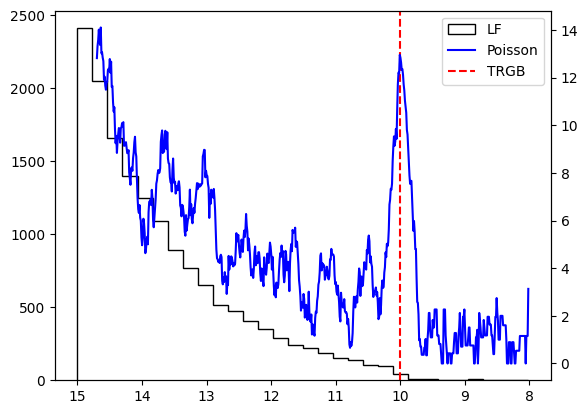

In [19]:
fig, ax1 = plt.subplots()
h = ax1.hist(m, bins=30, histtype='step', color='black', label='LF')

ax2 = ax1.twinx()
l1, = ax2.plot(x, f, '-b', label='Poisson')
l2 = ax1.axvline(m_trgb, color='red', linestyle='--', label='TRGB')

ax1.invert_xaxis()
handles = [l1, l2]
labels = [h[2][0].get_label(), 'Poisson', 'TRGB']
ax1.legend([h[2][0], l1, l2], labels)

plt.show()

In [20]:

  
#=================== FILTR SOBELA =======================================  
  
def make_sobel(sigma,j,logscale=False):
    numerical_step=0.0005
    m=np.arange(j.min(),j.max()+numerical_step,numerical_step,dtype=float)
    x= (j-j.min())/numerical_step
    indeks = x.astype(int)
    a=np.zeros(len(m))
    for i in indeks:
        a[i]=a[i]+1 
    gauss_x=np.arange(-5*sigma,5*sigma,numerical_step,dtype=float)
    gaussian = lambda x,sigma: 1.*np.exp(-x**2/(2.*sigma**2))
    gauss_y=gaussian(gauss_x,sigma) 
    splot=np.convolve(a,gauss_y,"same")    #to zajmuje mase czasu
    miu=int(0.5*sigma/numerical_step)
    pomocnicza1=splot[2*miu:len(splot)]
    pomocnicza2=splot[0:len(splot)-2*miu]
    maska=pomocnicza1<0.01
    pomocnicza1[maska]=0.01
    maska=pomocnicza2<0.01
    pomocnicza2[maska]=0.01
    sobel_x=m[miu:len(splot)-miu]
    if logscale: 
        sobel=np.log10(pomocnicza1)-np.log10(pomocnicza2)
    else: 
        sobel=pomocnicza1-pomocnicza2
    
    sobel=sobel*splot.max()/sobel.max()
    maska=sobel<0
    sobel[maska]=0
    trim = int((len(sobel) - len(sobel_x))/2.)
    if trim > 0 : 
        sobel=sobel[trim:np.alen(sobel)-trim]
    return m,splot,sobel_x,sobel  
  
  
def sobel_detect(x,sobel,trgb0):
    
    Nmax=max(x)
    trgb=9.
    if trgb0>90 or trgb0==0:
        i=np.argmax(sobel)
        trgb=x[i]
    else:
        x=np.array(x)
        tmp=(x-trgb0)
        tmp=tmp*tmp
        i=np.argmin(tmp)
        k=i
        l=i
        x0=sobel[i]
        zmiana=1
        while zmiana==1 and k+1<len(sobel) and l-1>0:
            if sobel[k] > sobel[k+1] and sobel[k]>sobel[k-1]: 
                zmiana=0
                trgb=x[k]
            elif sobel[l] > sobel[l+1] and sobel[l]>sobel[l-1]: 
                zmiana=0
                trgb=x[l]
            else: 
                zmiana=1   
            k=k+1
            l=l-1
    return trgb      
 
  

In [21]:
x,l,xf,f = make_sobel(0.03,m,False)
trgb = sobel_detect(x,f,10)
print(trgb)

9.986514247934815


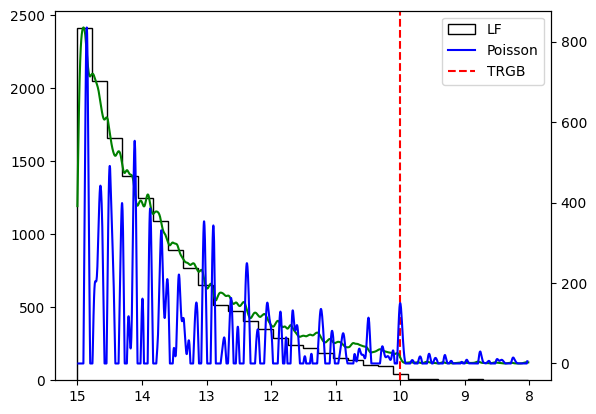

In [22]:
fig, ax1 = plt.subplots()
h = ax1.hist(m, bins=30, histtype='step', color='black', label='LF')

ax2 = ax1.twinx()
l0, = ax2.plot(x, l, '-g', label='Poisson')
l1, = ax2.plot(xf, f, '-b', label='Poisson')
l2 = ax1.axvline(m_trgb, color='red', linestyle='--', label='TRGB')

ax1.invert_xaxis()
handles = [l1, l2]
labels = [h[2][0].get_label(), 'Poisson', 'TRGB']
ax1.legend([h[2][0], l1, l2], labels)

plt.show()

In [23]:

  
#=================== MLA ===========================================
#trgb,a,b,c=mla([10,0.3,1,0.3],0.01,rozklad)  tak jak w pracy Makarov et al. 2006
#sigma_mla to jest rozmycie fi w zwiazku z bledami fot.
#ten pierwszy array to wartosci poczatkowe
#
#x,y=fi_mla(x,trgb,a,b,c,sigma_mla)
#

from scipy.optimize import minimize


def mla(p0,sigma,gtol,rozklad,trgb0):

    res = minimize(
        wiarygodnosc,
        p0,
        args=(rozklad,sigma),
        method='SLSQP',
        bounds=[
            (trgb0-0.5,trgb0+0.5),
            (-1,1),
            (-3,3),
            (-1,1)
        ],
        tol=gtol
    )

    return res.x


def wiarygodnosc(p, r, sigma):

    trgb, a, b, c = p

    _, A = fi_mla(r, trgb, a, b, c, sigma)

    A = np.maximum(A, 1e-300)

    x = np.arange(np.min(r), np.max(r), 0.01)

    _, y = fi_mla(x, trgb, a, b, c, sigma)

    B = np.log(np.sum(y))

    L = -np.sum(np.log(A)) + len(r) * B

    return L


def fi_mla(r, trgb, a, b, c, sigma):

    x = np.arange(np.min(r), np.max(r), 0.01)

    x1 = x[x > trgb]
    y1 = np.exp(np.clip(np.log(10)*(a*(x1-trgb)+b),-700,700))

    x2 = x[x < trgb]
    y2 = np.exp(np.clip(np.log(10)*(c*(x2-trgb)),-700,700))

    xk = np.concatenate((x1, x2))
    yk = np.concatenate((y1, y2))

    idx = np.argsort(xk)

    xk = xk[idx]
    yk = yk[idx]

    if sigma > 0:

        gauss_x = np.arange(-3*sigma, 3*sigma, 0.01)

        gauss_y = np.exp(
            -gauss_x**2/(2*sigma**2)
        )

        gauss_y /= np.sum(gauss_y)

        yk = np.convolve(
            yk,
            gauss_y,
            mode="same"
        )

    y_interp = np.interp(r, xk, yk)

    return r, y_interp
  

TRGB = 10.018013475781508
a = 0.3077123499706757
b = 1.0699181555396389
c = 0.1060234886658325


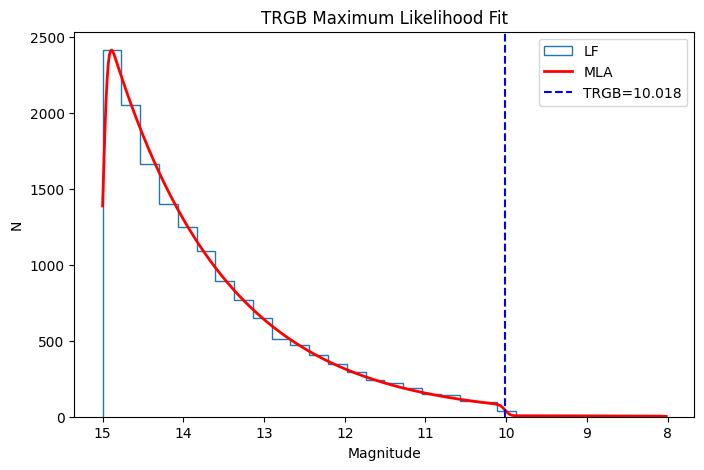

In [24]:
# początkowe zgadywanie
p = mla(
    [10.0,0.3,1,0.3],
    0.05,
    1e-6,
    m,
    trgb0=10.02
)

trgb, a, b, c = p

print("TRGB =", trgb)
print("a =", a)
print("b =", b)
print("c =", c)


# model LF
x_model = np.linspace(
    np.min(m),
    np.max(m),
    500
)

_, y_model = fi_mla(
    x_model,
    trgb,
    a,
    b,
    c,
    0.05
)


plt.figure(figsize=(8,5))

plt.hist(
    m,
    bins=30,
    histtype='step',
    label="LF"
)

# skalowanie modelu
hist_max = np.histogram(m,bins=30)[0].max()

y_model = y_model * hist_max / y_model.max()

plt.plot(
    x_model,
    y_model,
    '-r',
    linewidth=2,
    label="MLA"
)

plt.axvline(
    trgb,
    color='blue',
    linestyle='--',
    label=f"TRGB={trgb:.3f}"
)

plt.gca().invert_xaxis()

plt.xlabel("Magnitude")
plt.ylabel("N")
plt.legend()
plt.title("TRGB Maximum Likelihood Fit")

plt.show()

In [25]:

def gloess(x, y, sigma):

    """
    Gaussian-windowed locally weighted scatterplot smoothing

    x     - bin centers / magnitudes
    y     - luminosity function
    sigma - smoothing scale (mag)
    """

    y_smooth = np.zeros_like(y, dtype=float)

    for i, xi in enumerate(x):

        # odległość od aktualnego punktu
        dx = x - xi

        # Gaussian weights
        w = np.exp(
            -0.5*(dx/sigma)**2
        )

        # lokalna średnia ważona
        y_smooth[i] = np.sum(w*y) / np.sum(w)

    return y_smooth

def gloess_linear(x,y,sigma):

    ys = np.zeros_like(y,dtype=float)

    for i,xi in enumerate(x):

        dx = x-xi

        w = np.exp(
            -0.5*(dx/sigma)**2
        )


        X = np.vstack(
            [
                np.ones(len(x)),
                dx
            ]
        ).T


        W = np.diag(w)


        beta = np.linalg.solve(
            X.T @ W @ X,
            X.T @ W @ y
        )


        ys[i] = beta[0]


    return ys

def gloess_edge(x,y,sigma):

    smooth = gloess_linear(
        x,y,sigma
    )

    edge = np.gradient(
        smooth,
        x
    )

    return smooth, edge    


In [39]:
hist, edges = np.histogram(
    m,
    bins=100
)

x = 0.5*(edges[1:]+edges[:-1])
y = hist

smooth, edge = gloess_edge(
    x,
    y,
    sigma=0.05
)


i = np.argmax(edge)

trgb_gloess = sobel_detect(x,edge,10)

print("TRGB GLOESS =", trgb_gloess)

TRGB GLOESS = 10.007875822021301


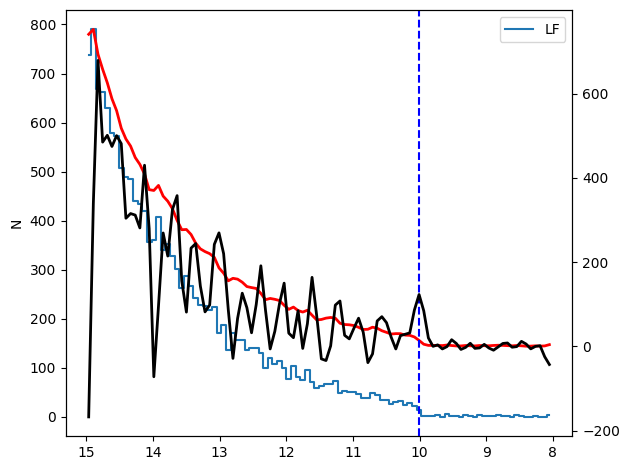

In [40]:
import matplotlib.pyplot as plt
import numpy as np




fig, ax1 = plt.subplots()

ax2 = ax1.twinx()



# --- LF ---
ax1.step(
    x,
    y,
    where="mid",
    label="LF"
)

ax2.plot(
    x,
    smooth,
    "-r",
    lw=2,
    label="GLOESS"
)

ax2.axvline(
    trgb_gloess,
    color="blue",
    ls="--",
    label=f"TRGB={trgb_gloess:.3f}"
)

ax1.invert_xaxis()
ax1.set_ylabel("N")
ax1.legend()


# --- EDGE ---
ax2.plot(
    x,
    edge,
    "-k",
    lw=2,
    label="d(GLOESS)/dm"
)



plt.tight_layout()
plt.show()